# Loading for Single Cell Analysis Directly from FCS files

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn.objects as so

import palmettobug as pbug

### CHANGE The following directory to match an existing directory on your computer if you are testing this tutorial on your own machine!

In [2]:
my_computer_path =  "C:/Users/caiello/Desktop"  ## CHANGE This DIRECTORY to match an existing directory on your computer if you testing this tutorial on your own machine!

## Create new CyTOF directory, fetch and load example FCS data:

In [3]:
new_directory = f"{my_computer_path}/FCS_example"       

if not os.path.exists(new_directory):
    os.mkdir(new_directory)

In [4]:
## Load example dataset
pbug.fetch_CyTOF_example(new_directory)
Analysis_experiment = pbug.Analysis()
Analysis_experiment.load_data(new_directory + "/main")

Could not load regionprops data, presuming this is a solution-mode dataset -- Spatial analyses will not be possible.


## Example Plots:

For a more full example of Single Cell Analysis, including cell clustering, annotaiton & merging, etc. see the Core Pipeline notebooks.
This notebook is primarily just showing how to load the example CyTOF data, not with its analysis.

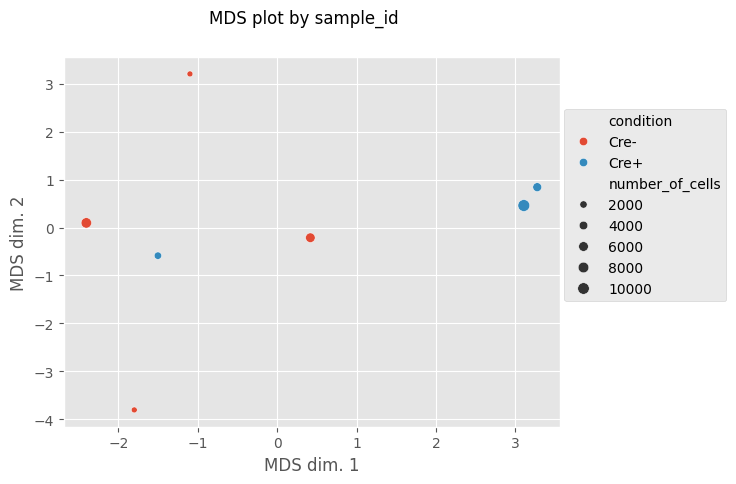

In [5]:
fig, MDS_df = Analysis_experiment.plot_MDS(marker_class = "type", color_by = "condition", print_stat = True)
fig

In [6]:
'''
Since I don't plan on dropping any of the sample_id's I will proceed with the FlowSOM:
'''

Analysis_experiment.do_flowsom(n_clusters = 20, XY_dim = 10, seed = 1234)

2025-02-21 16:33:38.019 | DEBUG    | palmettobug._vendor.flowsom:__init__:712 - Reading input.
2025-02-21 16:33:38.035 | DEBUG    | palmettobug._vendor.flowsom:__init__:714 - Fitting model: clustering and metaclustering.
2025-02-21 16:33:43.792 | DEBUG    | palmettobug._vendor.flowsom:__init__:716 - Updating derived values.


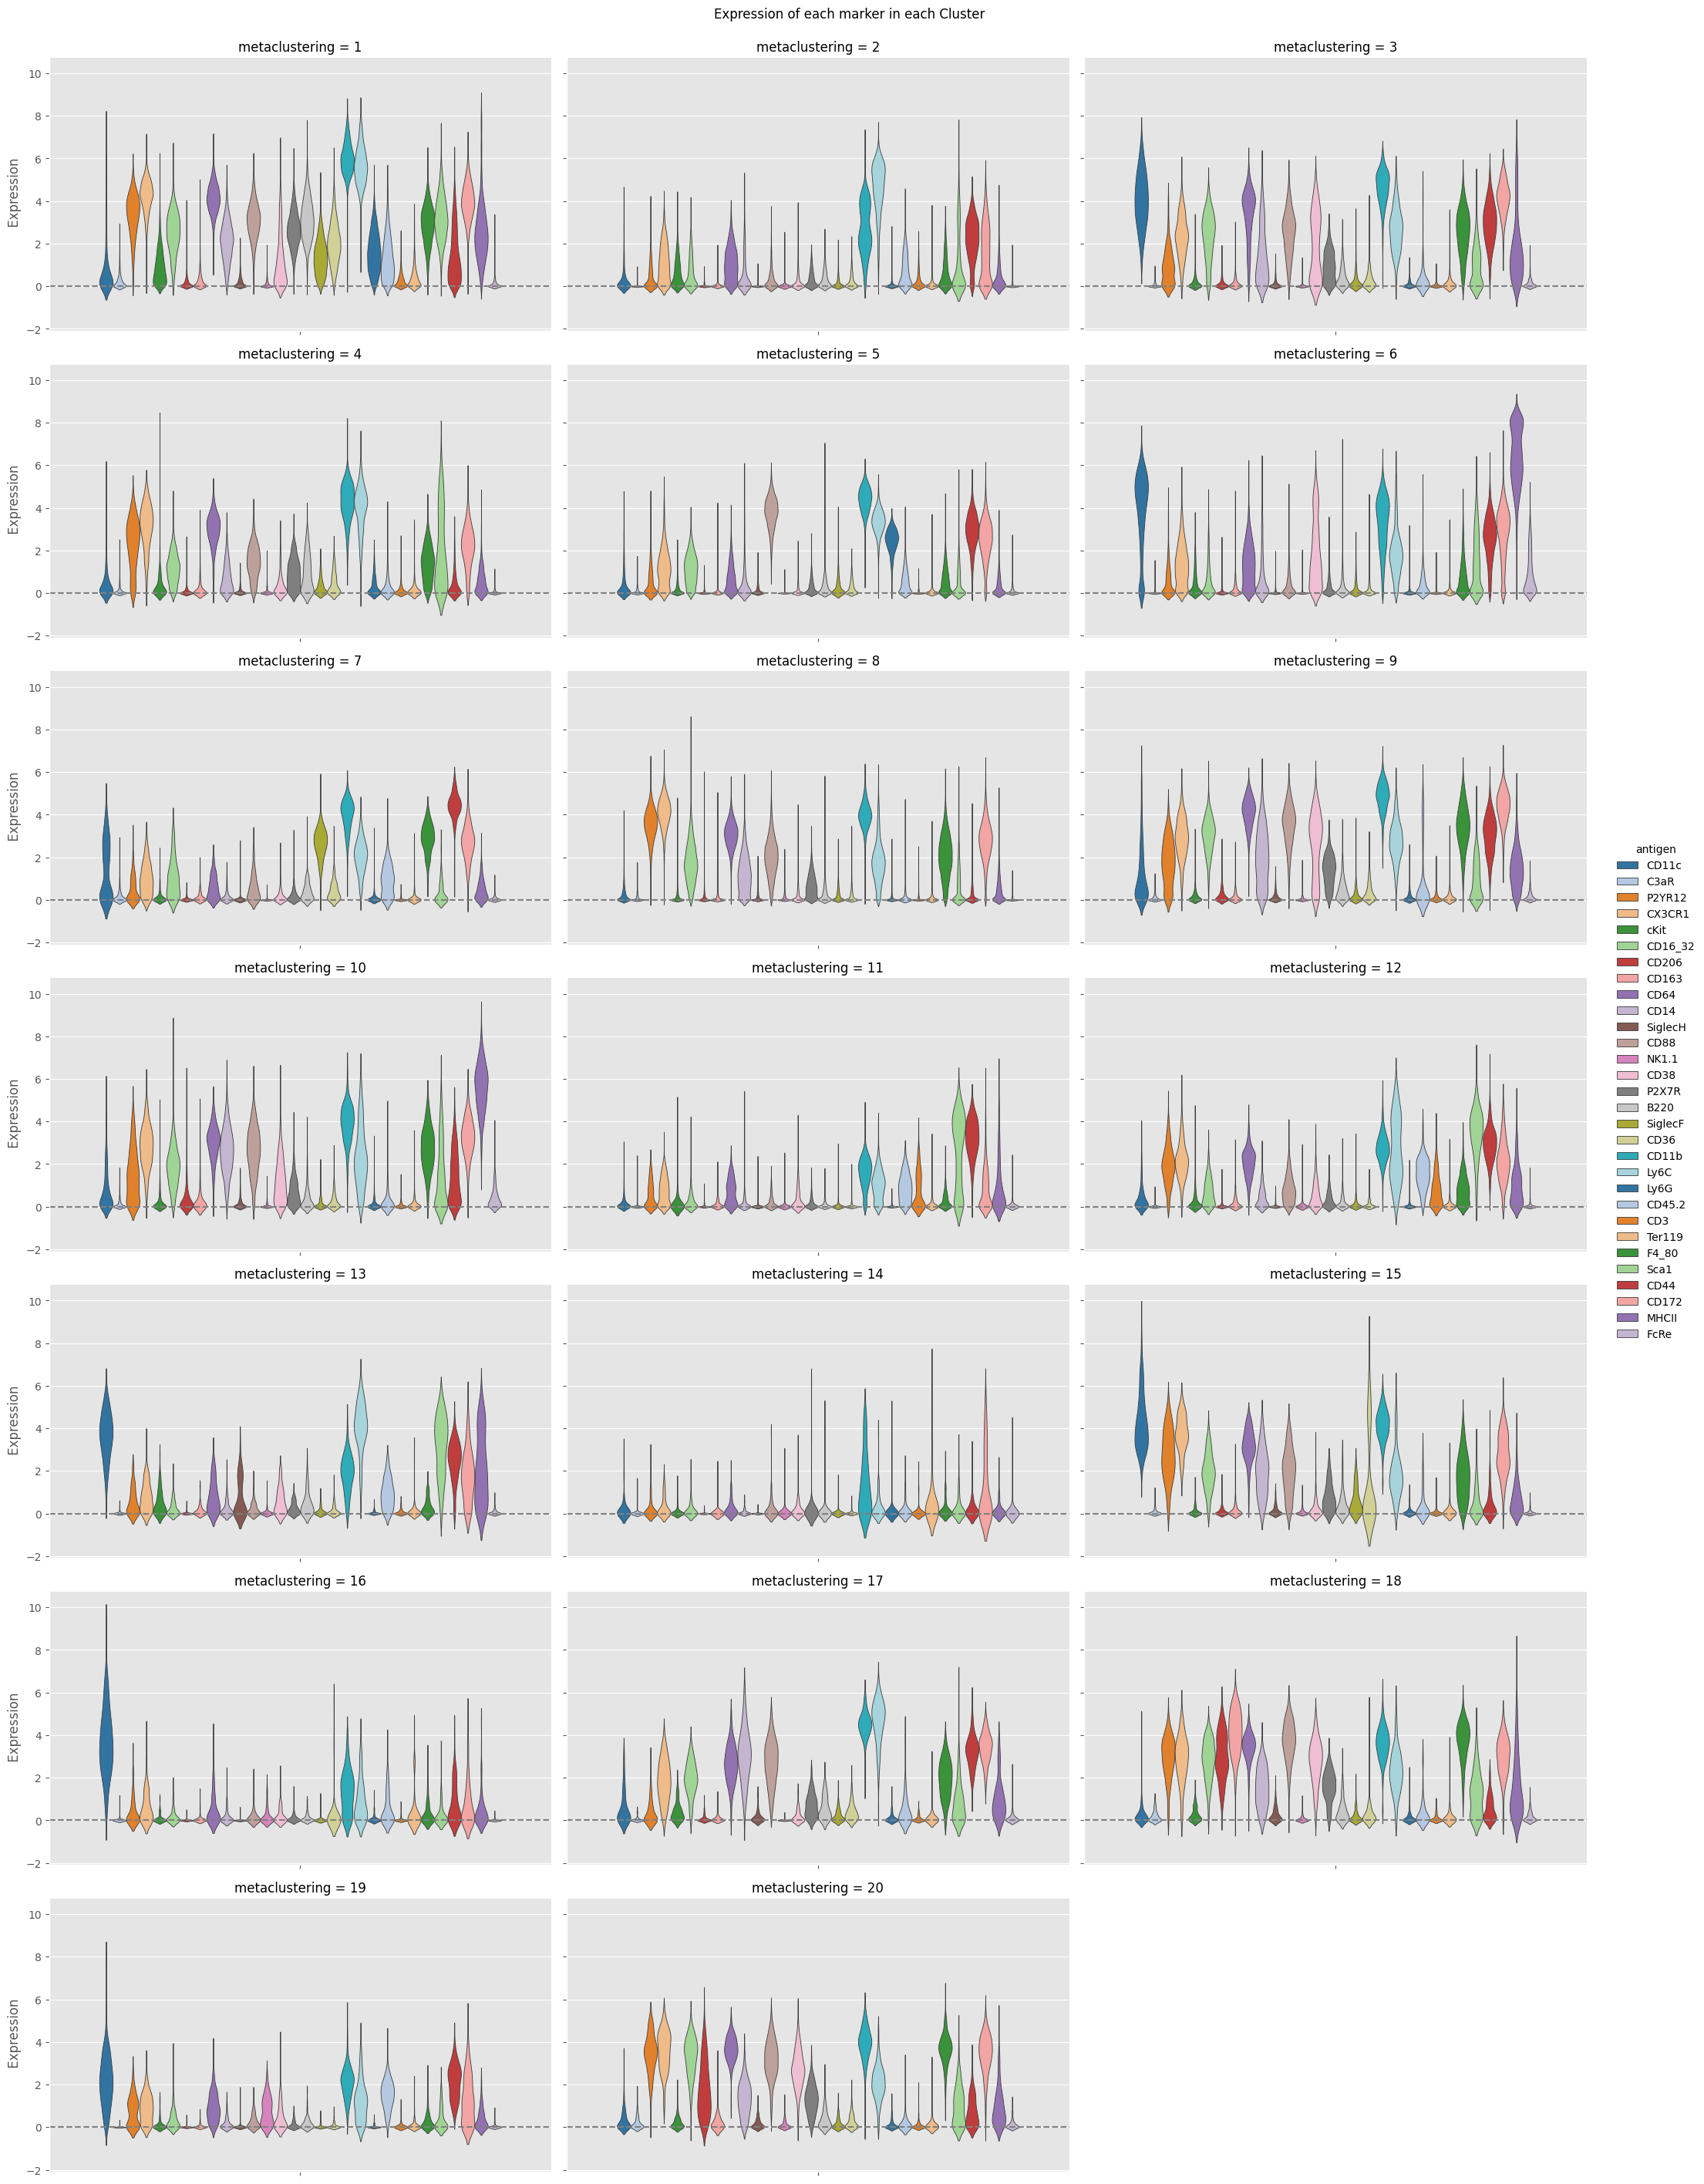

In [7]:
fig = Analysis_experiment.plot_cluster_distributions(filename = "violin", groupby_column = "metaclustering", marker_class = 'type', 
                                    plot_type = "violin", comp_type = "raw")
fig

In [8]:
stats_out = Analysis_experiment.do_cluster_stats(groupby_column = "metaclustering", marker_class = 'type')
cluster_to_examine = 2
display(stats_out[cluster_to_examine])   ## or display(Analysis_experiment.df_out_dict[cluster_to_examine]) 

,F_statistic,p_values,FDR_corrected,Difference in expression mean,st_error
Ly6C,12.020000,0.000724,0.02173,1.83900,0.215900
cKit,8.546000,0.004117,0.06175,0.28890,0.059180
CD88,7.633000,0.006603,0.06565,-1.40800,0.026490
CD172,7.096000,0.008753,0.06565,-1.16700,0.073120
F4_80,5.711000,0.018360,0.10260,-1.13200,0.052670
CX3CR1,5.199000,0.024300,0.10260,-1.08200,0.102900
CD16_32,5.140000,0.025110,0.10260,-0.90770,0.081220
P2YR12,4.986000,0.027350,0.10260,-0.98170,0.060840
CD64,4.762000,0.030970,0.10320,-1.13000,0.115900
CD11c,3.914000,0.050090,0.15030,-1.16300,0.057590


In [9]:
Analysis_experiment.do_UMAP(marker_class = "type", cell_number = 1000, seed = 0)

C:\Users\caiello\AppData\Local\miniconda3\envs\pbug_forge\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


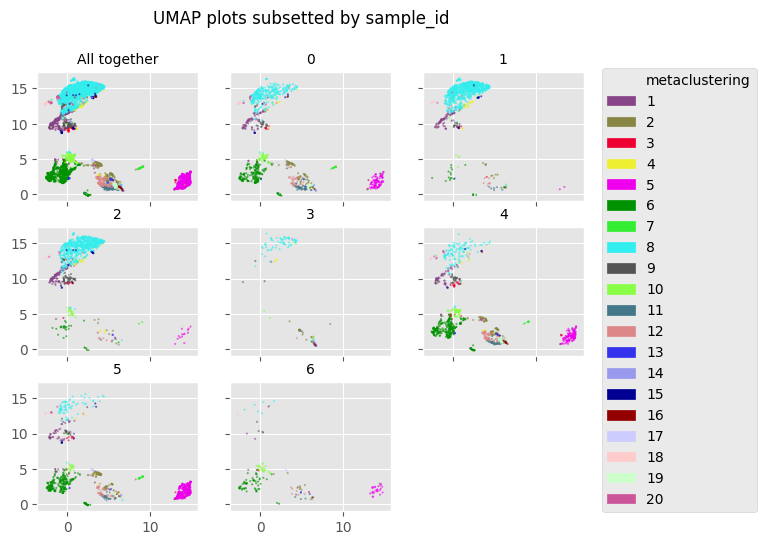

In [10]:
fig = Analysis_experiment.plot_facetted_DR(filename = "facetted_umap", color_by = "metaclustering", subsetting_column = "sample_id", 
                                    number_of_columns = 3, color_bank = None, kind = "UMAP")
fig

In [11]:
## export:
'''NOTE! This export is taken up by the CSV_load example notebook!'''

include_marker_class_row = True     ## use this when re-importing into PalmettoBUG, otherwise leave False if importing into another software
Analysis_experiment.export_data(include_marker_class_row = include_marker_class_row, filename = 'export')

antigen,BCKG190Di,Ba138Di,CD11c,B1,B2,B3,Ce140Di,Cs133Di,C3aR,P2YR12,...,FcRe,Time,index,sample_id,file_name,patient_id,condition,clustering,metaclustering,scaling
0,0.104628,4.385145,4.922898,3.618608,3.537663,0.164546,0.152547,0.0,0.0,1.456075,...,0.03361,5.838685,0,0,Barcode #8.fcs,na,Cre-,86,13,unscale
1,0.0,4.262575,0.119465,2.900198,3.223523,0.89206,0.0,0.0,0.480444,4.659772,...,0.0,7.913713,1,0,Barcode #8.fcs,na,Cre-,15,8,unscale
2,0.307769,4.301986,0.0,2.49893,2.539679,0.636219,0.314482,0.0,0.168631,3.710083,...,0.0,7.964846,2,0,Barcode #8.fcs,na,Cre-,26,8,unscale
3,0.0,3.847396,0.107216,3.164439,2.955016,0.410437,0.0,0.0,0.000323,1.709049,...,0.0,7.987539,3,0,Barcode #8.fcs,na,Cre-,85,11,unscale
4,0.215716,4.300961,0.0,3.264023,3.041938,0.317818,0.0,0.046254,0.0,1.843711,...,0.0,8.07008,4,0,Barcode #8.fcs,na,Cre-,58,10,unscale
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31158,0.0,1.376853,0.921611,3.049088,2.781277,2.187102,0.0,0.0,0.19916,0.502716,...,0.127752,14.776086,31158,6,Barcode #12.fcs,na,Cre-,48,10,unscale
31159,0.137254,4.873402,2.617839,3.272552,3.010591,2.904082,0.040989,0.0,0.0,2.031093,...,1.231978,14.77737,31159,6,Barcode #12.fcs,na,Cre-,88,6,unscale
31160,0.0,4.978204,3.547251,2.866139,2.472389,2.424449,0.0,0.0,0.0,0.302323,...,2.921348,14.780076,31160,6,Barcode #12.fcs,na,Cre-,89,6,unscale
31161,0.0,5.134777,0.106435,3.475678,3.56011,2.679149,0.0,0.0,0.090698,0.583354,...,0.028817,14.782751,31161,6,Barcode #12.fcs,na,Cre-,58,10,unscale
